In [1]:
import os
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt

In [8]:
ehr_labeled = pd.read_csv('./dataset4k-30-days.csv').drop(columns=['Unnamed: 0','LOS'])

In [16]:
3336/4000 -1

-0.16600000000000004

In [140]:
transformer_size = 'tiny'
SEED = 4

In [141]:
# --------------------
# Config
# --------------------

SEQ_LEN = 128
EMBED_DIM = 192 if transformer_size == 'tiny' else 384
FF_DIM = 768 if transformer_size == 'tiny' else 1536
NUM_HEADS = 3 if transformer_size == 'tiny' else 6
NUM_LAYERS = 4 if transformer_size == 'tiny' else 6
BATCH_SIZE = 128
LR = 1e-5
WD = 1e-6
EPOCHS = 50

VAL_DIM = 32
FUSED_DIM = EMBED_DIM + VAL_DIM
PAD_ID = 0

patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0



np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False




# # --------------------
# # Prepare Vocab & Label tokens only
# # --------------------
# concept_vocab = {c: i + 1 for i, c in enumerate(ehr_labeled['concept'].unique())}
# concept_vocab['[PAD]'] = 0
# CLS_ID = len(concept_vocab)
# concept_vocab['[CLS]'] = CLS_ID
# ehr_labeled['concept_idx'] = ehr_labeled['concept'].map(concept_vocab)

# # Group per patient
# concepts_per_patient = ehr_labeled.groupby('patient_id')['concept_idx'].apply(list)
# labels_per_patient = ehr_labeled.groupby('patient_id')['visit_label'].first()

# # Truncate and pad to fixed length (prepend CLS token)
# def truncate_or_pad(seq, max_len):
#     seq = [CLS_ID] + seq[:max_len - 1]
#     if len(seq) < max_len:
#         seq += [0] * (max_len - len(seq))
#     return torch.tensor(seq, dtype=torch.long)



# # Dataset class
# class TokenOnlyDataset(Dataset):
#     def __init__(self, concept_seqs, labels):
#         self.X = [truncate_or_pad(seq, SEQ_LEN) for seq in concept_seqs]
#         self.y = torch.tensor(labels.values, dtype=torch.long)
#     def __len__(self): return len(self.X)
#     def __getitem__(self, idx): return self.X[idx], self.y[idx]

# train_dataset = TokenOnlyDataset(concepts_per_patient[train_ids], labels_per_patient[train_ids])
# val_dataset   = TokenOnlyDataset(concepts_per_patient[val_ids],   labels_per_patient[val_ids])
# test_dataset  = TokenOnlyDataset(concepts_per_patient[test_ids],  labels_per_patient[test_ids])

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
# test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# --------------------
# Step 1: Build Vocabulary  fusion-based
# --------------------
concept_vocab = {c: i + 1 for i, c in enumerate(ehr_labeled['concept'].unique())}
concept_vocab['[PAD]'] = PAD_ID
CLS_ID = len(concept_vocab)
concept_vocab['[CLS]'] = CLS_ID
ehr_labeled['concept_idx'] = ehr_labeled['concept'].map(concept_vocab)

# --------------------
# Step 2: Normalize Value Per Concept
# --------------------
value_stats = ehr_labeled.groupby('concept_idx')['value'].agg(['mean', 'std']).fillna(0.0)
value_stats = value_stats.replace(0, 1e-6)  # prevent division by 0

def normalize_value(concept_idx, value):
    mu = value_stats.loc[concept_idx, 'mean']
    sigma = value_stats.loc[concept_idx, 'std']
    return (value - mu) / sigma

ehr_labeled['norm_value'] = ehr_labeled.apply(
    lambda row: normalize_value(row['concept_idx'], row['value']) if pd.notnull(row['value']) else 0.0,
    axis=1
)

# --------------------
# Step 3: Group per patient
# --------------------
concepts_per_patient = ehr_labeled.groupby('patient_id')['concept_idx'].apply(list)
values_per_patient = ehr_labeled.groupby('patient_id')['norm_value'].apply(list)
labels_per_patient = ehr_labeled.groupby('patient_id')['visit_label'].first()

# --------------------
# Step 4: Dataset Class
# --------------------
def truncate_pad_pair(concepts, values, max_len):
    concepts = [CLS_ID] + concepts[:max_len - 1]
    values = [0.0] + values[:max_len - 1]
    if len(concepts) < max_len:
        pad_len = max_len - len(concepts)
        concepts += [PAD_ID] * pad_len
        values += [0.0] * pad_len
    return torch.tensor(concepts, dtype=torch.long), torch.tensor(values, dtype=torch.float)

# class FusionDataset(Dataset):
#     def __init__(self, concept_seqs, value_seqs, labels):
#         self.X = [truncate_pad_pair(c, v, SEQ_LEN) for c, v in zip(concept_seqs, value_seqs)]
#         self.y = torch.tensor(labels.values, dtype=torch.long)
#     def __len__(self): return len(self.X)
#     def __getitem__(self, idx):
#         concepts, values = self.X[idx]
#         return concepts, values, self.y[idx]



class FiLMTokenDataset(Dataset):
    def __init__(self, concept_seqs, value_seqs, labels):
        self.X = [truncate_pad_pair(c, v, SEQ_LEN) for c, v in zip(concept_seqs, value_seqs)]
        self.y = torch.tensor(labels.values, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        concepts, values = self.X[idx]
        return concepts, values, self.y[idx]

# --------------------
# Stratified Split (700/100/200)
# --------------------
train_ids, temp_ids = train_test_split(
    concepts_per_patient.index,
    test_size=0.3,
    random_state=1,
#     stratify=labels_per_patient.loc[concepts_per_patient.index]
)

val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=1/2,
    random_state=1,
#     stratify=labels_per_patient.loc[temp_ids]
)
    
train_dataset = FiLMTokenDataset(concepts_per_patient[train_ids], values_per_patient[train_ids], labels_per_patient[train_ids])
val_dataset   = FiLMTokenDataset(concepts_per_patient[val_ids], values_per_patient[val_ids], labels_per_patient[val_ids])
test_dataset  = FiLMTokenDataset(concepts_per_patient[test_ids], values_per_patient[test_ids], labels_per_patient[test_ids])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)



In [142]:
# # --------------------
# # Transformer Model (CLS)
# # --------------------
# class TransformerClassifier(nn.Module):
#     def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_layers, num_classes=2):
#         super().__init__()
#         self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
#         encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=ff_dim, activation='gelu', batch_first=True)
#         self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
#         self.cls_head = nn.Sequential(
#             nn.Linear(embed_dim, 256),
#             nn.ReLU(),
# #             nn.Dropout(0.2),
#             nn.Linear(256, num_classes)
#         )
#     def forward(self, x):
#         mask = (x == 0)
#         x = self.embed(x)
#         enc_out = self.encoder(x, src_key_padding_mask=mask)
#         cls_output = enc_out[:, 0, :]  # Use [CLS] token output
#         return self.cls_head(cls_output)



# class FusionTransformer(nn.Module):
#     def __init__(self, vocab_size, embed_dim, val_dim, fused_dim, num_heads, ff_dim, num_layers, num_classes=2):
#         super().__init__()
#         self.concept_embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
#         self.value_project = nn.Sequential(
#             nn.Linear(1, val_dim),
#             nn.ReLU(),
#             nn.Linear(val_dim, val_dim)
#         )
#         self.fuse = nn.Sequential(
#             nn.Linear(embed_dim + val_dim, fused_dim),
#             nn.ReLU(),
#             nn.Linear(fused_dim, embed_dim)
#         )
#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=embed_dim, nhead=num_heads, dim_feedforward=ff_dim,
#             activation='gelu', batch_first=True
#         )
#         self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
#         self.cls_head = nn.Sequential(
#             nn.Linear(embed_dim, 256),
#             nn.ReLU(),
#             nn.Linear(256, num_classes)
#         )

#     def forward(self, concept_ids, values):
#         mask = (concept_ids == PAD_ID)  # [B, T]
#         concept_emb = self.concept_embed(concept_ids)  # [B, T, D]
#         value_proj = self.value_project(values.unsqueeze(-1))  # [B, T, Dv]
#         fused_input = torch.cat([concept_emb, value_proj], dim=-1)  # [B, T, D+Dv]
#         fused = self.fuse(fused_input)  # [B, T, D]
#         encoded = self.encoder(fused, src_key_padding_mask=mask)  # [B, T, D]
#         cls_token = encoded[:, 0, :]  # [B, D]
#         return self.cls_head(cls_token)  # [B, num_classes]



# ----------------------------
# FiLM Transformer Model
# ----------------------------
class FiLMTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, val_dim, num_heads, ff_dim, num_layers, dropout=0.1, num_classes=2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        
        self.gamma_mlp = nn.Sequential(
            nn.Linear(1, val_dim),
            nn.ReLU(),
            nn.Linear(val_dim, embed_dim)
        )
        self.beta_mlp = nn.Sequential(
            nn.Linear(1, val_dim),
            nn.ReLU(),
            nn.Linear(val_dim, embed_dim)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            activation='gelu',
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.cls_head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, concepts, values):
        mask = (concepts == 0)  # padding mask
        concept_emb = self.embed(concepts)  # [B, T, D]

        # Project values into gamma and beta
        values_exp = values.unsqueeze(-1)  # [B, T, 1]
        gamma = self.gamma_mlp(values_exp)  # [B, T, D]
        beta = self.beta_mlp(values_exp)    # [B, T, D]

        # Create a mask where value != 0
        has_value = (values != 0.0).unsqueeze(-1).float()  # [B, T, 1]

        # Apply FiLM modulation with masking
        gamma = gamma * has_value + (1.0 - has_value)      # gamma = 1 where no value
        beta = beta * has_value                            # beta = 0 where no value
        modulated = gamma * concept_emb + beta             # [B, T, D]

        # Transformer encoding
        encoded = self.encoder(modulated, src_key_padding_mask=mask)  # [B, T, D]
        cls_token = encoded[:, 0, :]  # [B, D]

        return self.cls_head(cls_token)  # [B, num_classes]


/home/sas10092/.conda/envs/spring-projects/lib/python3.9/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


Epoch 1: Train L = 0.6696 | Val L = 0.5100 | Val AUROC = 0.5184 | Val AUPRC = 0.1607 | Val F1 (macro) = 0.4575
Epoch 2: Train L = 0.4804 | Val L = 0.4366 | Val AUROC = 0.5880 | Val AUPRC = 0.2032 | Val F1 (macro) = 0.4575
Epoch 3: Train L = 0.4517 | Val L = 0.4247 | Val AUROC = 0.6826 | Val AUPRC = 0.2918 | Val F1 (macro) = 0.4575
Epoch 4: Train L = 0.4443 | Val L = 0.4158 | Val AUROC = 0.7665 | Val AUPRC = 0.3922 | Val F1 (macro) = 0.4575
Epoch 5: Train L = 0.4343 | Val L = 0.4063 | Val AUROC = 0.8176 | Val AUPRC = 0.4554 | Val F1 (macro) = 0.4575
Epoch 6: Train L = 0.4245 | Val L = 0.3942 | Val AUROC = 0.8499 | Val AUPRC = 0.4992 | Val F1 (macro) = 0.4575
Epoch 7: Train L = 0.4095 | Val L = 0.3771 | Val AUROC = 0.8706 | Val AUPRC = 0.5286 | Val F1 (macro) = 0.4575
Epoch 8: Train L = 0.3902 | Val L = 0.3520 | Val AUROC = 0.8844 | Val AUPRC = 0.5431 | Val F1 (macro) = 0.4792
Epoch 9: Train L = 0.3649 | Val L = 0.3299 | Val AUROC = 0.8933 | Val AUPRC = 0.5504 | Val F1 (macro) = 0.5849
E

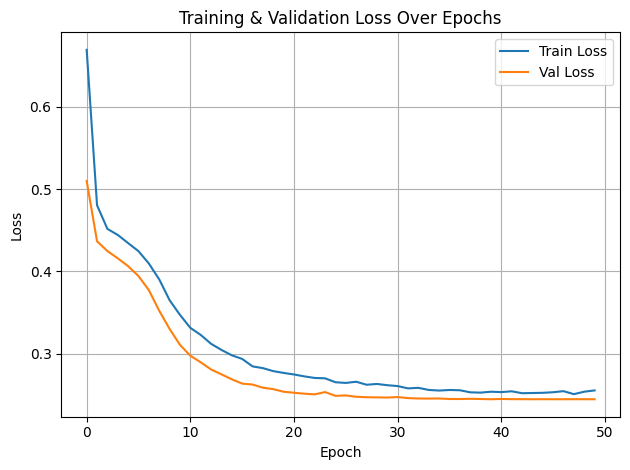

In [143]:
# --------------------
# Train + Validate
# --------------------

# Set up
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FiLMTransformer(
    vocab_size=len(concept_vocab),
    embed_dim=EMBED_DIM,
    val_dim=VAL_DIM, 
#     fused_dim=FUSED_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_layers=NUM_LAYERS,
    num_classes=2).to(device)

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()


train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch_c, batch_v, batch_y in train_loader:
        batch_c, batch_v, batch_y = batch_c.to(device), batch_v.to(device), batch_y.to(device)
        optimizer.zero_grad()
        logits = model(batch_c,batch_v)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ---- Validation ----
    model.eval()
    val_loss = 0
    val_probs = []
    val_labels = []
    val_preds = []

    with torch.no_grad():
        for batch_c, batch_v, batch_y in val_loader:
            batch_c, batch_v, batch_y = batch_c.to(device), batch_v.to(device), batch_y.to(device)
            logits = model(batch_c,batch_v)
            loss = criterion(logits, batch_y)
            val_loss += loss.item()

            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            val_probs.extend(probs)
            val_preds.extend(preds)
            val_labels.extend(batch_y.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    val_auroc = roc_auc_score(val_labels, val_probs)
    val_auprc = average_precision_score(val_labels, val_probs)
    val_f1 = f1_score(val_labels, val_preds, average='macro')

    print(f"Epoch {epoch+1}: Train L = {avg_train_loss:.4f} | "
          f"Val L = {avg_val_loss:.4f} | "
          f"Val AUROC = {val_auroc:.4f} | "
          f"Val AUPRC = {val_auprc:.4f} | "
          f"Val F1 (macro) = {val_f1:.4f}")

    scheduler.step()

    # ---- Early Stopping Check ----
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict()  # Save best weights
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(best_model_state)

# --------------------
# Final Test Evaluation
# --------------------
model.eval()
all_probs, all_labels, all_preds = [], [], []

with torch.no_grad():
    for batch_c, batch_v, batch_y in test_loader:
        batch_c, batch_v, batch_y = batch_c.to(device), batch_v.to(device), batch_y.to(device)
        logits = model(batch_c,batch_v)

        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(batch_y.cpu().numpy())

# Final metrics
auroc = roc_auc_score(all_labels, all_probs)
auprc = average_precision_score(all_labels, all_probs)
f1 = f1_score(all_labels, all_preds, average='macro')

print(f"{auroc:.4f},")
print(f"{auprc:.4f},")
print(f"{f1:.4f},")

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
aurocs = [0.9422,0.9418,0.9422,0.9380,0.9326]
auprcs = [0.6881,0.6394,0.6533,0.6525,0.6327]
f1s    = [0.8045,0.8246,0.7932,0.7874,0.7489]

print(f'{round(np.mean(aurocs),3)}',f'({round(np.std(aurocs),3)})')
print(f'{round(np.mean(auprcs),3)}',f'({round(np.std(auprcs),3)})')
print(f'{round(np.mean(f1s),3)}',f'({round(np.std(f1s),3)})')

0.939 (0.004)
0.653 (0.019)
0.792 (0.025)


In [145]:
from timm.models.vision_transformer import vit_tiny_patch16_224, vit_small_patch16_224

In [9]:
# tokens only

# tiny
# 0.932 (0.004)
# 0.622 (0.012)
# 0.762 (0.024)

# small
# 0.941 (0.002)
# 0.644 (0.013)
# 0.804 (0.015)


# fusion-based

# Tiny
# 0.935 (0.004)
# 0.633 (0.015)
# 0.774 (0.009)

# Small
# 0.946 (0.001)
# 0.679 (0.022)
# 0.774 (0.040)


# film-based

# Tiny
# 0.915 (0.005)
# 0.572 (0.008)
# 0.739 (0.011)

# 0.932 (0.003)
# 0.631 (0.015)
# 0.776 (0.008)

# 0.932 (0.003)
# 0.633 (0.014)
# 0.781 (0.009)


# Small
# 0.937 (0.005)
# 0.659 (0.036)
# 0.781 (0.013)

# 0.939 (0.004)
# 0.653 (0.019)
# 0.806 (0.021)

# 0.939 (0.004)
# 0.653 (0.019)
# 0.792 (0.025)

In [260]:
1e-4

0.0001

In [ ]:
small







tiny


